In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Step 1: Data Tidying & Data Cleaning Report

### 1. Type Corrections
We converted the `pickup_datetime` and `dropoff_datetime` columns from object strings to **datetime objects**. This was a fundamental step to enable time-series analysis and to extract temporal features such as hours and days of the week, which are critical predictors for trip duration.

### 2. Basic Cleansing & Duplicate Removal
We performed a check for redundant data and removed all exact duplicates to prevent the model from being biased toward repeated observations.

### 3. Handling Inconsistent Entries (Outlier Management)
To ensure data integrity, we applied the following filters:
* **Temporal Filtering:** Trips shorter than 1 minute or longer than 3 hours were removed, as they often represent system errors or stationary taxis rather than actual trips.
* **Geographical Filtering:** We restricted the coordinates to the NYC bounding box. Any coordinates outside this range were treated as GPS noise.
* **Spatial Validation:** By constructing the `distance_km` feature using the **Haversine Formula**, we identified and removed trips with zero distance (which are logically invalid for duration prediction).

### 4. Imputation Techniques
For missing values in the `passenger_count` column, we applied **Mode Imputation**. We chose the mode (most frequent value) because the number of passengers is a discrete, categorical-like variable, and using the mean would result in illogical decimal values (e.g., 1.5 passengers).

### 5. Data Tidying with Pivot Tables
We utilized **Pivot Tables** to restructure the data and verify its cleanliness. By aggregating the average trip duration by hour and day, we ensured that the cleaned dataset reflects realistic traffic patterns (e.g., higher durations during rush hours), confirming that our cleaning process preserved the essential characteristics of the data.

In [2]:
import pandas as pd
import numpy as np

# 1. Load the raw dataset
# Ensure the file path is correct for your Colab session
df = pd.read_csv('NYC.csv')

# --- Step 2: Data Tidying & Data Cleaning ---

# [A] Type Corrections
# Converting date columns from strings to datetime objects for time-series analysis
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

# Data Type Enforcement: Convert coordinate columns to numeric (float)
# This prevents errors during mathematical calculations (like Haversine)
cols_to_fix = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove rows that became NaN during numeric conversion to maintain data quality
df.dropna(subset=cols_to_fix, inplace=True)

# [B] Feature Construction: Calculating Trip Distance
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculates the great-circle distance between two points
    on the Earth using the Haversine formula.
    """
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c  # Result in Kilometers (Earth radius = 6371km)

# Apply the function to create a new distance column
df['distance_km'] = haversine_distance(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

# [C] Basic Cleansing
# Removing exact duplicate rows to avoid model bias
df.drop_duplicates(inplace=True)

# [D] Handling Inconsistent Entries & Outliers
# Ensure trip_duration is numeric before filtering
df['trip_duration'] = pd.to_numeric(df['trip_duration'], errors='coerce')

# 1. Temporal Filtering: Remove trips shorter than 1 minute or longer than 3 hours
df = df[(df['trip_duration'] > 60) & (df['trip_duration'] < 10800)]

# 2. Geographical Filtering: Restrict coordinates to the NYC metropolitan area
df = df[df['pickup_longitude'].between(-74.25, -73.70)]
df = df[df['pickup_latitude'].between(40.47, 40.92)]

# 3. Spatial Validation: Remove trips with zero distance or unrealistic lengths (>100km)
df = df[(df['distance_km'] > 0.1) & (df['distance_km'] < 100)]

# [E] Imputation: Handling Missing Values
# Fill missing passenger counts with the Mode (Most frequent value)
if df['passenger_count'].isnull().sum() > 0:
    df['passenger_count'].fillna(df['passenger_count'].mode()[0], inplace=True)

# [F] Data Tidying & Structural Analysis
# Extract hour and day name for granular analysis
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day_name()

# Create a Pivot Table to analyze average duration per hour across different days
# This helps verify if the cleaned data follows realistic traffic patterns
cleaning_summary_pivot = df.pivot_table(
    index='pickup_hour',
    columns='pickup_day',
    values='trip_duration',
    aggfunc='mean'
)

# Final Output Status
print("Data Cleaning Process Finished Successfully.")
print(f"Final records count: {df.shape[0]}")

Data Cleaning Process Finished Successfully.
Final records count: 1440222


In [4]:
# --- Validation & Sanity Checks ---

print("1. Checking for Missing Values:")
print(df.isnull().sum())
print("-" * 30)

print("2. Checking for Duplicates:")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")
print("-" * 30)

print("3. Checking Coordinate Ranges (Should be within NYC):")
print(f"Latitude Range:  {df['pickup_latitude'].min()} to {df['pickup_latitude'].max()}")
print(f"Longitude Range: {df['pickup_longitude'].min()} to {df['pickup_longitude'].max()}")
print("-" * 30)

print("4. Checking Trip Logic (Should be > 1 min and > 0.1 km):")
print(f"Minimum Duration: {df['trip_duration'].min()} seconds")
print(f"Minimum Distance: {df['distance_km'].min():.2f} km")
print("-" * 30)

print("5. Data Types Verification:")
print(df[['pickup_datetime', 'distance_km', 'passenger_count']].dtypes)

1. Checking for Missing Values:
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
distance_km           0
pickup_hour           0
pickup_day            0
dtype: int64
------------------------------
2. Checking for Duplicates:
Total Duplicate Rows: 0
------------------------------
3. Checking Coordinate Ranges (Should be within NYC):
Latitude Range:  40.60443115234375 to 40.88294219970703
Longitude Range: -74.01807403564453 to -73.77218627929686
------------------------------
4. Checking Trip Logic (Should be > 1 min and > 0.1 km):
Minimum Duration: 61.0 seconds
Minimum Distance: 0.10 km
------------------------------
5. Data Types Verification:
pickup_datetime    datetime64[ns]
distance_km               float64
passenger_count             int64
dtype: object


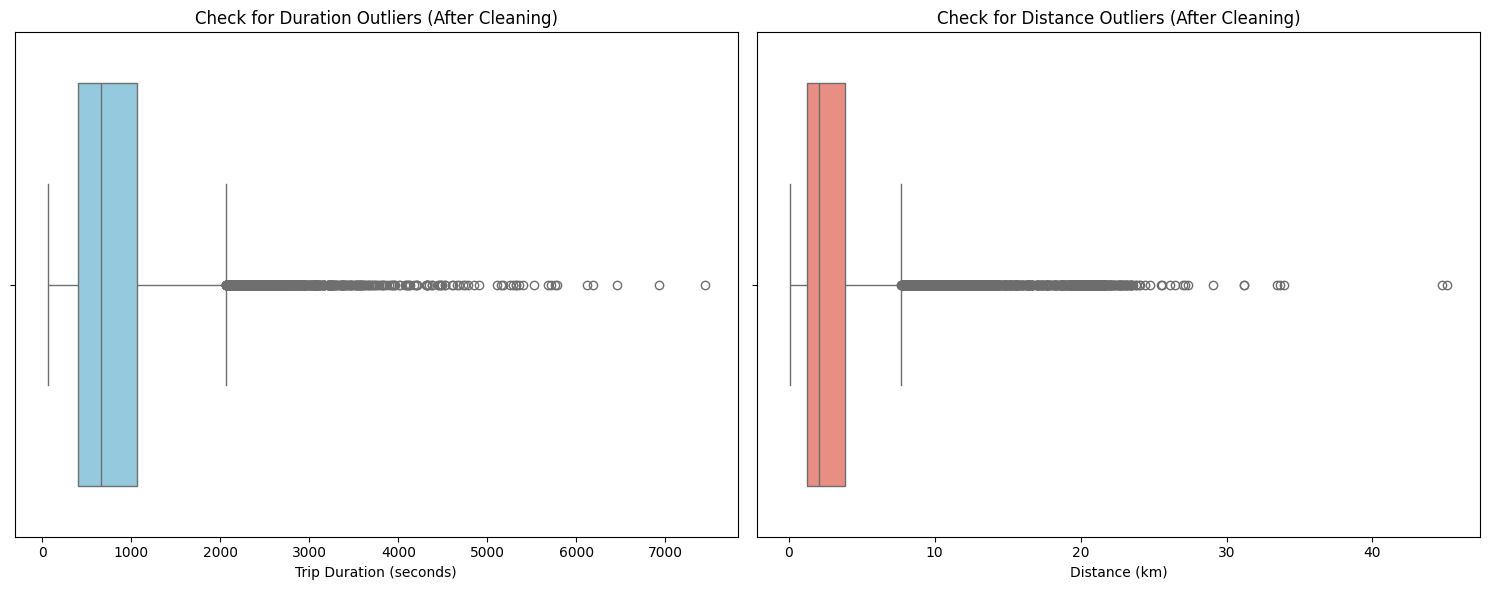

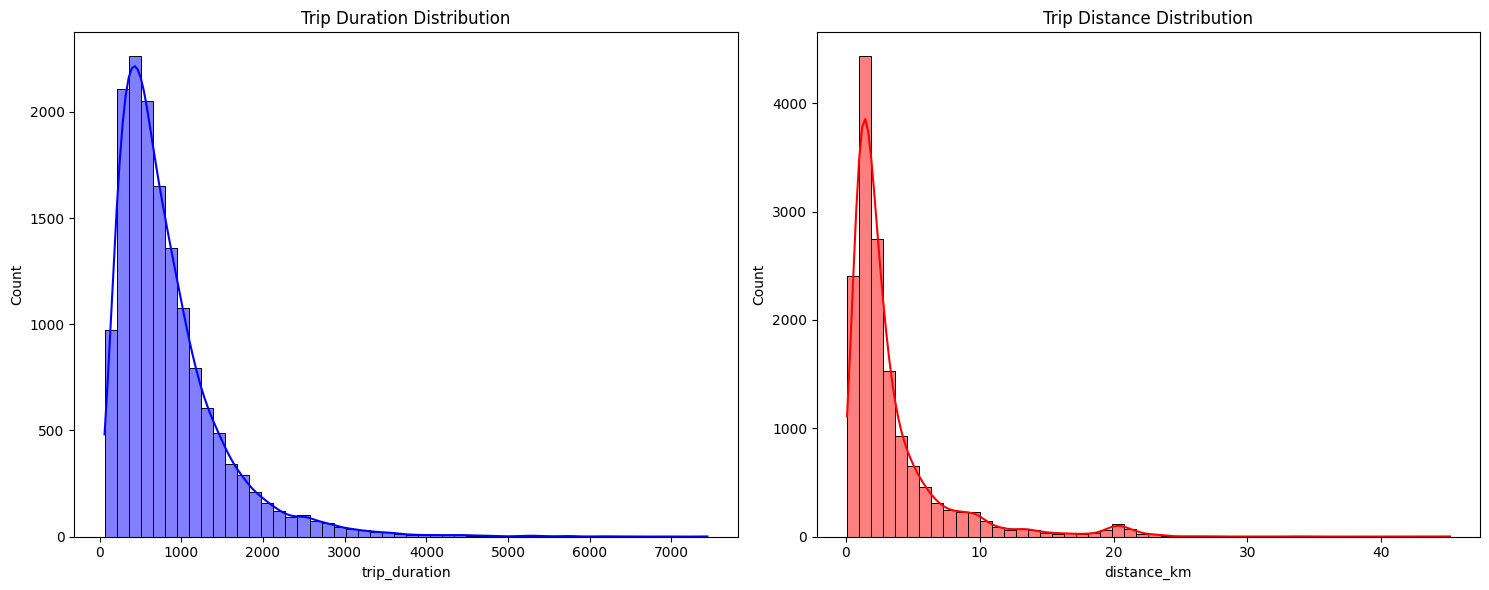

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with 2 subplots (one for Duration, one for Distance)
plt.figure(figsize=(15, 6))

# 1. Boxplot for Trip Duration
plt.subplot(1, 2, 1)
sns.boxplot(x=df['trip_duration'], color='skyblue')
plt.title('Check for Duration Outliers (After Cleaning)')
plt.xlabel('Trip Duration (seconds)')

# 2. Boxplot for Trip Distance
plt.subplot(1, 2, 2)
sns.boxplot(x=df['distance_km'], color='salmon')
plt.title('Check for Distance Outliers (After Cleaning)')
plt.xlabel('Distance (km)')

plt.tight_layout()
plt.show()

# 3. Histogram to see the distribution of cleaned data
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['trip_duration'], bins=50, kde=True, color='blue')
plt.title('Trip Duration Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['distance_km'], bins=50, kde=True, color='red')
plt.title('Trip Distance Distribution')

plt.tight_layout()
plt.show()

## Feature Extraction --> ***Anas***

In [19]:
df.sample(3)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,pickup_hour,pickup_day,pickup_cluster,dropoff_cluster
829502,id0772044,1,2016-05-31 11:54:48,2016-05-31 12:30:22,1,-74.016014,40.710754,-73.982483,40.765594,N,2134,6.720562,11,Tuesday,0,1
289996,id0085395,2,2016-01-21 15:34:14,2016-01-21 15:43:56,1,-74.001442,40.727856,-74.001099,40.718895,N,582,0.996807,15,Thursday,0,0
287346,id3974760,2,2016-02-02 16:56:39,2016-02-02 17:08:12,1,-73.992432,40.756641,-73.993042,40.738289,N,693,2.041353,16,Tuesday,1,1


### Rush Hour Feature
This feature checks if the trip happened during peak traffic hours (morning or evening).  
It helps the model understand traffic impact on trip duration.

In [20]:
df['rush_hour'] = df['pickup_hour'].apply(lambda x: 1 if (7 <= x <= 9 or 16 <= x <= 19) else 0)

### Trip Direction
This feature calculates the direction of the trip using pickup and dropoff coordinates.  
It may help capture movement patterns across the city.  
It is computed by taking the arctangent (atan2) of the difference in latitude (Y-axis) and longitude (X-axis) between dropoff and pickup points to obtain the trip angle.


In [21]:
df['direction'] = np.arctan2(
    df['dropoff_latitude'] - df['pickup_latitude'],
    df['dropoff_longitude'] - df['pickup_longitude']
)

### Average Speed
This feature estimates the trip speed (km/h) based on distance and duration.  
It helps identify abnormal trips and traffic conditions.

In [22]:
df['speed_kmh'] = df['distance_km'] / (df['trip_duration'] / 3600)

### Time Features
We extract if the trip is on a weekend and the month of the trip.  
This helps capture seasonal and weekly patterns.

In [23]:
df['is_weekend'] = df['pickup_datetime'].dt.dayofweek >= 5
df['month'] = df['pickup_datetime'].dt.month

### Distance per Passenger
This feature divides trip distance by number of passengers.  
It may reflect ride-sharing patterns or trip efficiency.

In [24]:
df['distance_per_passenger'] = df['distance_km'] / df['passenger_count']

### Log Transformation of Duration
We apply log transformation to reduce Skewed Distribution in trip duration.  
The goal is removing outliers.

In [25]:
df['log_trip_duration'] = np.log1p(df['trip_duration'])

### Location Clustering (KMeans)

In this step, we apply clustering on the pickup and dropoff coordinates to group similar locations into clusters.

Instead of using raw latitude and longitude values directly, we transform them into cluster labels. This helps simplify the spatial information and makes it easier for the model to understand location-based patterns.

The main idea is that nearby locations usually share similar traffic conditions and travel behavior. For example, trips starting in the same area (like city center or airport) often have similar durations.

By grouping coordinates into clusters, we allow the model to learn:
- differences between regions
- traffic behavior in each area
- patterns related to specific zones

This approach improves model performance because it reduces noise in raw coordinates and captures meaningful geographic structure in the data.

In [26]:
coords = pd.concat([
    df[['pickup_latitude', 'pickup_longitude']].rename(columns={
        'pickup_latitude': 'lat', 'pickup_longitude': 'lon'
    }),
    df[['dropoff_latitude', 'dropoff_longitude']].rename(columns={
        'dropoff_latitude': 'lat', 'dropoff_longitude': 'lon'
    })
])

In [27]:
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(coords_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [28]:
pickup_scaled = scaler.transform(
    df[['pickup_latitude', 'pickup_longitude']].rename(columns={
        'pickup_latitude': 'lat', 'pickup_longitude': 'lon'
    })
)
df['pickup_cluster'] = kmeans.predict(pickup_scaled)


dropoff_scaled = scaler.transform(
    df[['dropoff_latitude', 'dropoff_longitude']].rename(columns={
        'dropoff_latitude': 'lat', 'dropoff_longitude': 'lon'
    })
)
df['dropoff_cluster'] = kmeans.predict(dropoff_scaled)

In [29]:
df.sample(3)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,pickup_day,pickup_cluster,dropoff_cluster,rush_hour,direction,speed_kmh,is_weekend,month,distance_per_passenger,log_trip_duration
1403705,id3409402,2,2016-03-07 16:50:03,2016-03-07 17:06:37,1,-74.014015,40.712700,-73.981529,40.768639,N,...,Monday,0,1,1,1.044658,24.611884,False,3,6.795615,6.902743
45543,id0373965,2,2016-03-12 09:02:53,2016-03-12 09:10:27,5,-73.973801,40.747520,-73.992271,40.741177,N,...,Saturday,1,1,1,-2.810762,13.547454,True,3,0.341697,6.120297
597265,id1494141,2,2016-03-25 12:14:56,2016-03-25 12:57:00,5,-74.016022,40.711422,-73.993378,40.749779,N,...,Friday,0,1,0,1.037500,6.664304,False,3,0.934484,7.833996
